In [144]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds
from datetime import datetime, timedelta
import logging
from typing import Optional, List, Dict, Any
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

# OptionMetrics Volatility Surface (Example: AAPL)

In [321]:
# Connect to WRDS
db = wrds.Connection(wrds_username='joycexu020113')

Loading library list...
Done


## Volatility Surface Data

In [210]:
aapl_df=pd.read_csv('aapl_vol_surf.csv')

In [212]:
aapl_df.head()

,secid,date,days,delta,impl_volatility,impl_strike,impl_premium,dispersion,cp_flag,cusip,ticker,sic,index_flag
0,101594,2018-08-31,10,-90,0.221498,238.6275,11.317620,0.017071,P,3783310,AAPL,3571,0
1,101594,2018-08-31,10,-85,0.220567,236.5462,9.472385,0.017071,P,3783310,AAPL,3571,0
2,101594,2018-08-31,10,-80,0.219571,234.8808,8.072828,0.016698,P,3783310,AAPL,3571,0
3,101594,2018-08-31,10,-75,0.218668,233.4598,6.945686,0.016193,P,3783310,AAPL,3571,0
4,101594,2018-08-31,10,-70,0.217552,232.1875,5.993965,0.016042,P,3783310,AAPL,3571,0


In [214]:
aapl_df.shape

(470492, 13)

In [216]:
# ATM calls: delta between +45 and +55
atm_calls = aapl_df[(aapl_df['cp_flag'] == 'C') & (aapl_df['delta'].between(45, 55))]

# ATM puts: delta between -55 and -45
atm_puts = aapl_df[(aapl_df['cp_flag'] == 'P') & (aapl_df['delta'].between(-55, -45))]

# Combine ATM calls and puts
df_iv = pd.concat([atm_calls, atm_puts])

In [218]:
df_iv['date'] = pd.to_datetime(df_iv['date'])

In [372]:
df_iv.head(20)

,secid,date,days,delta,impl_volatility,impl_strike,impl_premium,dispersion,cp_flag,cusip,ticker,sic,index_flag
24,101594,2018-08-31,10,45,0.230652,229.0180,2.881782,0.013878,C,3783310,AAPL,3571,0
25,101594,2018-08-31,10,50,0.230471,227.9211,3.383313,0.014191,C,3783310,AAPL,3571,0
26,101594,2018-08-31,10,55,0.231495,226.8274,3.955775,0.014454,C,3783310,AAPL,3571,0
58,101594,2018-08-31,30,45,0.228021,230.4051,4.856256,0.003054,C,3783310,AAPL,3571,0
59,101594,2018-08-31,30,50,0.228867,228.5225,5.722063,0.003228,C,3783310,AAPL,3571,0
60,101594,2018-08-31,30,55,0.230328,226.6400,6.697395,0.003675,C,3783310,AAPL,3571,0
92,101594,2018-08-31,60,45,0.232794,232.2492,6.894392,0.010991,C,3783310,AAPL,3571,0
93,101594,2018-08-31,60,50,0.234138,229.5208,8.132749,0.011277,C,3783310,AAPL,3571,0
94,101594,2018-08-31,60,55,0.236009,226.7932,9.525372,0.011544,C,3783310,AAPL,3571,0
126,101594,2018-08-31,91,45,0.236853,233.4777,8.473354,0.007293,C,3783310,AAPL,3571,0


## Price Data

In [96]:
query_prices = """
SELECT date, secid, close
FROM optionm.secprd
WHERE secid = 101594
  AND date BETWEEN '2018-08-31' AND '2023-08-31'
"""
df_price = db.raw_sql(query_prices)

In [98]:
df_price.head()

,date,secid,close
0,2018-08-31,101594.0,227.63
1,2018-09-04,101594.0,228.36
2,2018-09-05,101594.0,226.87
3,2018-09-06,101594.0,223.1
4,2018-09-07,101594.0,221.3


In [108]:
df_price = df_price.sort_values('date')  # Ensure chronological order
df_price['log_return'] = np.log(df_price['close'] / df_price['close'].shift(1))

# Annualized volatility (multiply by sqrt(252))
df_price['ewm_vol'] = df_price['log_return'].ewm(halflife=7).std() * np.sqrt(252)

In [110]:
df_price

,date,secid,close,log_return,ewm_vol
0,2018-08-31,101594.0,227.63,<NA>,NaN
1,2018-09-04,101594.0,228.36,0.003202,NaN
2,2018-09-05,101594.0,226.87,-0.006546,0.109421
3,2018-09-06,101594.0,223.1,-0.016757,0.158425
4,2018-09-07,101594.0,221.3,-0.008101,0.126213
...,...,...,...,...,...
1253,2023-08-25,101594.0,178.61,0.012564,0.240278
1254,2023-08-28,101594.0,180.19,0.008807,0.233477
1255,2023-08-29,101594.0,184.12,0.021576,0.245096
1256,2023-08-30,101594.0,187.65,0.018991,0.247048


## Earnings Date Data

In [323]:
start_date = '2018-08-31'
end_date = '2023-08-31'
tickers = ['AAPL']
formatted_tickers = ', '.join(f"'{t}'" for t in tickers)

earnings_query = f"""
    SELECT cusip,
           tic AS ticker,
           datadate,
           rdq AS earnings_date,
           fyearq,
           fqtr
    FROM comp.fundq
    WHERE tic IN ({formatted_tickers})
      AND rdq BETWEEN '{start_date}' AND '{end_date}'
      AND rdq IS NOT NULL
    ORDER BY tic, rdq;
"""
df_earnings = db.raw_sql(earnings_query)

In [325]:
df_earnings

,cusip,ticker,datadate,earnings_date,fyearq,fqtr
0,037833100,AAPL,2018-09-30,2018-11-01,2018,4
1,037833100,AAPL,2018-12-31,2019-01-29,2019,1
2,037833100,AAPL,2019-03-31,2019-04-30,2019,2
3,037833100,AAPL,2019-06-30,2019-07-30,2019,3
4,037833100,AAPL,2019-09-30,2019-10-30,2019,4
5,037833100,AAPL,2019-12-31,2020-01-28,2020,1
6,037833100,AAPL,2020-03-31,2020-04-30,2020,2
7,037833100,AAPL,2020-06-30,2020-07-30,2020,3
8,037833100,AAPL,2020-09-30,2020-10-29,2020,4
9,037833100,AAPL,2020-12-31,2021-01-27,2021,1


# Compute Realized Earnings Volatility Ratio (REVR)

In [327]:
df_price['date'] = pd.to_datetime(df_price['date'])
df_price = df_price.sort_values('date').reset_index(drop=True)

df_earnings['earnings_date'] = pd.to_datetime(df_earnings['earnings_date'])

In [329]:
# Create a list of valid trading dates
trading_days = df_price['date'].tolist()

# Function to align earnings date to next available trading day
def align_to_trading_day(event_date):
    for d in trading_days:
        if d >= event_date:
            return d
    return pd.NaT  # if event_date is after the last trading day

# Apply to df_earnings
df_earnings['event_trading_day'] = df_earnings['earnings_date'].apply(align_to_trading_day)

In [331]:
# Reset index of df_price to access rows by position
price_reset = df_price.reset_index(drop=True)

# Create a mapping from date to row index
date_to_idx = {d: i for i, d in enumerate(price_reset['date'])}

# Function to compute REVR
def compute_revr(event_day):
    if pd.isna(event_day):
        return np.nan
    
    idx = date_to_idx.get(event_day, None)
    if idx is None:
        return np.nan

    # Ensure enough history and forward data
    if idx < 3 or idx + 4 >= len(price_reset):
        return np.nan

    vol_t_minus_3 = price_reset.loc[idx - 3, 'ewm_vol']
    vol_t_plus_4 = price_reset.loc[idx + 4, 'ewm_vol']

    if pd.isna(vol_t_minus_3) or pd.isna(vol_t_plus_4) or vol_t_minus_3 == 0:
        return np.nan

    return vol_t_plus_4 / vol_t_minus_3

In [333]:
df_earnings['REVR'] = df_earnings['event_trading_day'].apply(compute_revr)

In [335]:
df_earnings[['earnings_date', 'event_trading_day', 'REVR']].dropna().head()

,earnings_date,event_trading_day,REVR
0,2018-11-01,2018-11-01,1.375961
1,2019-01-29,2019-01-29,1.086467
2,2019-04-30,2019-04-30,1.743757
3,2019-07-30,2019-07-30,1.795054
4,2019-10-30,2019-10-30,1.216739


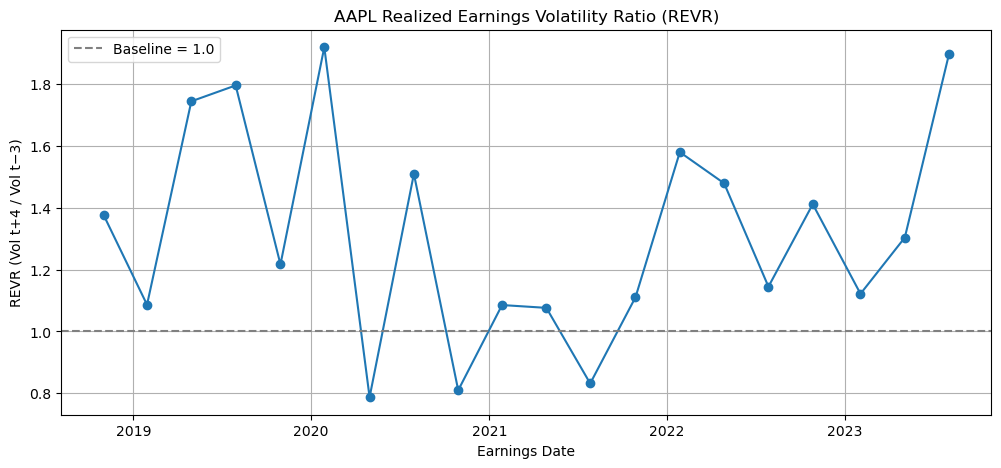

In [337]:
df_revr = df_earnings[['event_trading_day', 'REVR']].dropna()

plt.figure(figsize=(12, 5))
plt.plot(df_revr['event_trading_day'], df_revr['REVR'], marker='o')
plt.title('AAPL Realized Earnings Volatility Ratio (REVR)')
plt.xlabel('Earnings Date')
plt.ylabel('REVR (Vol t+4 / Vol t−3)')
plt.grid(True)
plt.axhline(1, color='gray', linestyle='--', label='Baseline = 1.0')
plt.legend()
plt.show()

Regression target (REVR) calculated, which seem to be match expectations (between 0.9 and 2x of baseline volatility)

# Single event analysis: 2022-10-27

In [280]:
# Place 30 days before earnings date and look at volatility surface
anchor_date = pd.to_datetime("2022-09-27")
df_surface = df_iv[df_iv['date'] == anchor_date].copy()

In [282]:
# Filter to Short-to-Medium Maturities (10–90 days)
df_surface = df_surface[(df_surface['days'] >= 10) & (df_surface['days'] <= 90)]

In [394]:
df_surface.shape

(18, 15)

In [2]:
df_surface

NameError: name 'df_surface' is not defined

In [286]:
# Perform kernel regression as outlined in Wolfe's paper
from statsmodels.nonparametric.kernel_regression import KernelReg

# Use days to expiry (X) and implied vol (Y)
x = df_surface['days'].values
y = df_surface['impl_volatility'].values

# Kernel regression: Y ~ X
kr = KernelReg(endog=y, exog=x, var_type='c')  # 'c' for continuous
y_pred, _ = kr.fit(x)

# Store smooth IV values
df_surface['normative_iv'] = y_pred

In [288]:
# Compute Residuals (Deviation from Normative)
df_surface['iv_residual'] = df_surface['impl_volatility'] - df_surface['normative_iv']

In [306]:
kink_row = df_surface.loc[df_surface['iv_residual'].idxmax()]
iv_kink = kink_row['impl_volatility']
iv_norm = kink_row['normative_iv']
days_kink = kink_row['days']
IEVR = iv_kink / iv_norm

print(f"Kink located at {days_kink} days to expiry")
print(f"IV at kink: {iv_kink:.2%}")
print(f"Normative IV: {iv_norm:.2%}")
print(f"IEVR = {IEVR:.2f}")

Kink located at 30 days to expiry
IV at kink: 41.66%
Normative IV: 40.27%
IEVR = 1.03


In [302]:
df_revr[df_revr['event_trading_day']=='2022-10-27']

,event_trading_day,REVR
19,2022-10-27,1.411349


### Single event result interpretation:
- The options market priced in a small increase in volatility 30 days before the event (IEVR = 1.03).
- In reality, realized volatility jumped much higher after earnings (REVR = 1.41).
- This suggests the market underpriced earnings risk, which might reflect:
    - Surprise guidance
    - Underestimated macro impact
    - Volatility risk premium behavior

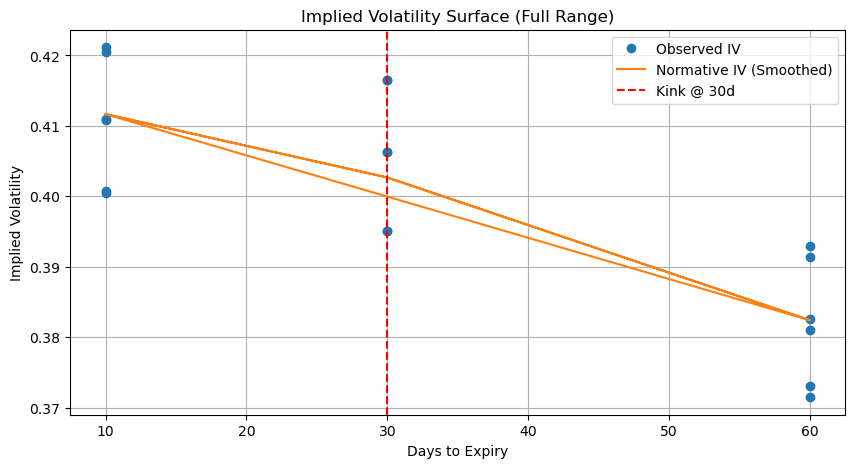

In [392]:
# Implied Volatility Surface graph (10-60 days to maturity)
plt.figure(figsize=(10, 5))
plt.plot(df_surface['days'], df_surface['impl_volatility'], 'o', label='Observed IV')
plt.plot(df_surface['days'], df_surface['normative_iv'], '-', label='Normative IV (Smoothed)')
plt.axvline(days_kink, color='red', linestyle='--', label=f'Kink @ {days_kink}d')
plt.title('Implied Volatility Surface (Full Range)')
plt.xlabel('Days to Expiry')
plt.ylabel('Implied Volatility')
plt.legend()
plt.grid(True)
plt.show()

Not sure if this is the best graph: the vol surface data is probably aggregated, so we only get options with days to maturity at [10, 30, 60, 91, 122, 152, 182] days, resulting in limited data points and not very obvious/accurate kink.

# Extend to multiple earnings events of AAPL and attempt regression

In [339]:
# Align earnings date to trading calendar
df_earnings['earnings_date'] = pd.to_datetime(df_earnings['earnings_date'])
trading_days = sorted(df_price['date'].unique())

def align_to_trading_day(date):
    for d in trading_days:
        if d >= date:
            return d
    return pd.NaT

df_earnings['event_trading_day'] = df_earnings['earnings_date'].apply(align_to_trading_day)
df_earnings = df_earnings.dropna(subset=['event_trading_day'])

In [341]:
# Compute REVR (Realized Earnings Volatility Ratio)
price_reset = df_price.sort_values('date').reset_index(drop=True)
date_to_idx = {d: i for i, d in enumerate(price_reset['date'])}

def compute_revr(event_day):
    idx = date_to_idx.get(event_day, None)
    if idx is None or idx < 3 or idx + 4 >= len(price_reset):
        return np.nan
    vol_pre = price_reset.loc[idx - 3, 'ewm_vol']
    vol_post = price_reset.loc[idx + 4, 'ewm_vol']
    if pd.isna(vol_pre) or pd.isna(vol_post) or vol_pre == 0:
        return np.nan
    return vol_post / vol_pre

df_earnings['REVR'] = df_earnings['event_trading_day'].apply(compute_revr)

In [343]:
df_earnings

,cusip,ticker,datadate,earnings_date,fyearq,fqtr,event_trading_day,REVR
0,037833100,AAPL,2018-09-30,2018-11-01,2018,4,2018-11-01,1.375961
1,037833100,AAPL,2018-12-31,2019-01-29,2019,1,2019-01-29,1.086467
2,037833100,AAPL,2019-03-31,2019-04-30,2019,2,2019-04-30,1.743757
3,037833100,AAPL,2019-06-30,2019-07-30,2019,3,2019-07-30,1.795054
4,037833100,AAPL,2019-09-30,2019-10-30,2019,4,2019-10-30,1.216739
5,037833100,AAPL,2019-12-31,2020-01-28,2020,1,2020-01-28,1.918526
6,037833100,AAPL,2020-03-31,2020-04-30,2020,2,2020-04-30,0.787516
7,037833100,AAPL,2020-06-30,2020-07-30,2020,3,2020-07-30,1.509298
8,037833100,AAPL,2020-09-30,2020-10-29,2020,4,2020-10-29,0.810056
9,037833100,AAPL,2020-12-31,2021-01-27,2021,1,2021-01-27,1.085383


In [345]:
def get_anchor_day(event_day, lookback=30):
    prior_days = [d for d in trading_days if d < event_day]
    return prior_days[-lookback] if len(prior_days) >= lookback else pd.NaT

df_earnings['anchor_date'] = df_earnings['event_trading_day'].apply(get_anchor_day)

In [347]:
from statsmodels.nonparametric.kernel_regression import KernelReg

def compute_ievr(anchor_date, df_iv):
    if pd.isna(anchor_date):
        return np.nan
    available_dates = df_iv['date'].unique()
    surface_date = max([d for d in available_dates if d <= anchor_date], default=None)
    if surface_date is None:
        return np.nan

    df_surface = df_iv[df_iv['date'] == surface_date].copy()
    df_surface = df_surface[(df_surface['days'] >= 10) & (df_surface['days'] <= 90)]
    df_surface = df_surface[
        ((df_surface['cp_flag'] == 'C') & df_surface['delta'].between(45, 55)) |
        ((df_surface['cp_flag'] == 'P') & df_surface['delta'].between(-55, -45))
    ]
    if df_surface.empty:
        return np.nan

    x = df_surface['days'].values
    y = df_surface['impl_volatility'].values

    try:
        kr = KernelReg(endog=y, exog=x, var_type='c')
        y_pred, _ = kr.fit(x)
        df_surface['normative_iv'] = y_pred
    except:
        return np.nan

    df_surface['iv_residual'] = df_surface['impl_volatility'] - df_surface['normative_iv']
    kink_row = df_surface.loc[df_surface['iv_residual'].idxmax()]
    iv_kink = kink_row['impl_volatility']
    iv_norm = kink_row['normative_iv']
    return iv_kink / iv_norm if iv_norm > 0 else np.nan

df_earnings['IEVR'] = df_earnings['anchor_date'].apply(lambda d: compute_ievr(d, df_iv))

In [349]:
df_results = df_earnings[['earnings_date', 'event_trading_day', 'anchor_date', 'REVR', 'IEVR']].dropna()

In [400]:
df_results

,earnings_date,event_trading_day,anchor_date,REVR,IEVR,log_IEVR,log_REVR
0,2018-11-01,2018-11-01,2018-09-20,1.375961,1.065051,0.063023,0.319153
1,2019-01-29,2019-01-29,2018-12-13,1.086467,1.014628,0.014522,0.082931
2,2019-04-30,2019-04-30,2019-03-18,1.743757,1.011157,0.011095,0.556042
3,2019-07-30,2019-07-30,2019-06-17,1.795054,1.016582,0.016446,0.585035
4,2019-10-30,2019-10-30,2019-09-18,1.216739,1.021123,0.020903,0.196174
5,2020-01-28,2020-01-28,2019-12-12,1.918526,1.021699,0.021467,0.651557
6,2020-04-30,2020-04-30,2020-03-18,0.787516,1.027838,0.027458,-0.238871
7,2020-07-30,2020-07-30,2020-06-17,1.509298,1.057728,0.056123,0.411644
8,2020-10-29,2020-10-29,2020-09-17,0.810056,1.011500,0.011435,-0.210651
9,2021-01-27,2021-01-27,2020-12-11,1.085383,1.007044,0.007019,0.081933


In [353]:
# Regression: REVR ~ IEVR
import statsmodels.api as sm
import matplotlib.pyplot as plt

X = sm.add_constant(df_results['IEVR'])
y = df_results['REVR']
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   REVR   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.054
Method:                 Least Squares   F-statistic:                   0.02144
Date:                Sun, 13 Jul 2025   Prob (F-statistic):              0.885
Time:                        22:55:22   Log-Likelihood:                -6.7916
No. Observations:                  20   AIC:                             17.58
Df Residuals:                      18   BIC:                             19.57
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9919      2.203      0.450      0.6

- R-squared = 0.001: IEVR explains almost none of the variation in REVR.
- IEVR P-value = 0.885: Market-implied vol signal (IEVR) is not a statistically significant predictor of realized vol.
- Conclusion: In this small sample for AAPL, the options market did not consistently anticipate realized volatility shocks from earnings.

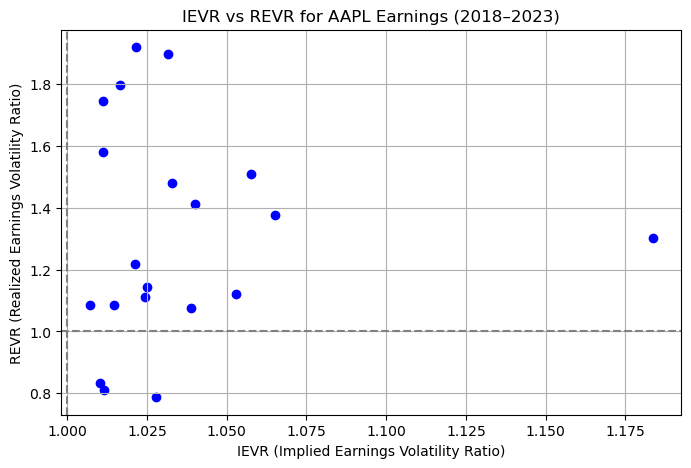

In [355]:
plt.figure(figsize=(8, 5))
plt.scatter(df_results['IEVR'], df_results['REVR'], color='blue')
plt.xlabel('IEVR (Implied Earnings Volatility Ratio)')
plt.ylabel('REVR (Realized Earnings Volatility Ratio)')
plt.title('IEVR vs REVR for AAPL Earnings (2018–2023)')
plt.axhline(1, color='gray', linestyle='--')
plt.axvline(1, color='gray', linestyle='--')
plt.grid(True)
plt.show()

In [369]:
# Log Transformation

df_results['log_IEVR'] = np.log(df_results['IEVR'])
df_results['log_REVR'] = np.log(df_results['REVR'])

X_log = sm.add_constant(df_results['log_IEVR'])
y_log = df_results['log_REVR']
model_log = sm.OLS(y_log, X_log).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:               log_REVR   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.048
Method:                 Least Squares   F-statistic:                    0.1368
Date:                Sun, 13 Jul 2025   Prob (F-statistic):              0.716
Time:                        23:03:03   Log-Likelihood:                -1.7284
No. Observations:                  20   AIC:                             7.457
Df Residuals:                      18   BIC:                             9.448
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2163      0.087      2.479      0.0

- Slightly better results after log transformation, but still very low R-squared and insignificant coefficient, suggesting low predictive power

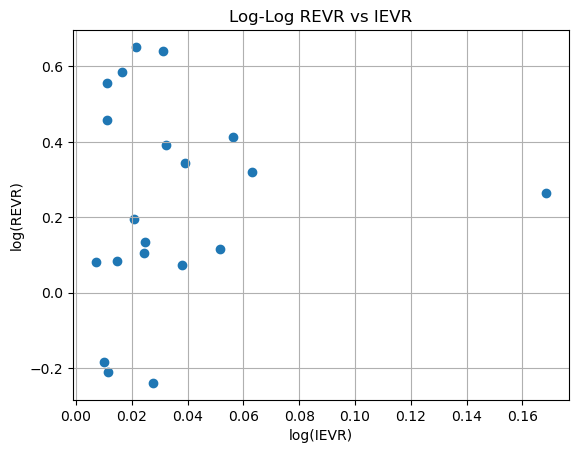

In [379]:
plt.scatter(df_results['log_IEVR'], df_results['log_REVR'])
plt.xlabel('log(IEVR)')
plt.ylabel('log(REVR)')
plt.title('Log-Log REVR vs IEVR')
plt.grid(True)
plt.show()